In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

C:\Users\shahs\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\shahs\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
market_spend = pd.read_csv("C:/Users/shahs/OneDrive/Desktop/Data Analytics/E-commerce profitablilty analysis/marketing_spend.csv")

In [3]:
orders = pd.read_csv("C:/Users/shahs/OneDrive/Desktop/Data Analytics/E-commerce profitablilty analysis/orders.csv")

In [4]:
products = pd.read_csv("C:/Users/shahs/OneDrive/Desktop/Data Analytics/E-commerce profitablilty analysis/products.csv")

In [5]:
market_spend.shape

(144, 10)

In [6]:
orders.shape

(2000, 20)

In [7]:
products.shape

(207, 9)

In [8]:
market_spend.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   month               144 non-null    str    
 1   platform            144 non-null    str    
 2   spend               144 non-null    float64
 3   impressions         144 non-null    int64  
 4   clicks              144 non-null    int64  
 5   conversions         144 non-null    int64  
 6   revenue_attributed  144 non-null    float64
 7   cpc                 144 non-null    float64
 8   cpa                 144 non-null    float64
 9   roas                144 non-null    float64
dtypes: float64(5), int64(3), str(2)
memory usage: 14.0 KB


In [9]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          2000 non-null   str    
 1   customer_id       2000 non-null   str    
 2   order_date        2000 non-null   str    
 3   channel           2000 non-null   str    
 4   payment_method    2000 non-null   str    
 5   region            2000 non-null   str    
 6   items_ordered     2000 non-null   int64  
 7   primary_category  2000 non-null   str    
 8   gross_revenue     2000 non-null   float64
 9   discount_pct      2000 non-null   int64  
 10  discount_amount   2000 non-null   float64
 11  shipping_cost     2000 non-null   float64
 12  product_cost      2000 non-null   float64
 13  platform_fee      2000 non-null   float64
 14  transaction_fee   2000 non-null   float64
 15  returned          2000 non-null   str    
 16  refund_amount     2000 non-null   float64
 17  net_re

In [10]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   product_id              207 non-null    str    
 1   product_name            207 non-null    str    
 2   category                207 non-null    str    
 3   sub_category            207 non-null    str    
 4   unit_cost               207 non-null    float64
 5   selling_price           207 non-null    float64
 6   shipping_cost_per_unit  207 non-null    float64
 7   weight_lbs              207 non-null    float64
 8   supplier                207 non-null    str    
dtypes: float64(4), str(5)
memory usage: 26.1 KB


## Convert date columns to datetime objects

In [11]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
market_spend['date'] = pd.to_datetime(market_spend['month'])
market_spend['year'] = market_spend['date'].dt.year
market_spend['month_num'] = market_spend['date'].dt.month

## Data Quality & Integrity Checks
#### Verifying that calculated costs match recorded totals and checking for duplicate entries to ensure analysis accuracy.

In [12]:
# Verify cost calculations
calculated_totals = (
    orders['shipping_cost'] + 
    orders['product_cost'] + 
    orders['platform_fee'] + 
    orders['transaction_fee']
)
mismatches = orders[~np.isclose(calculated_totals, orders['total_costs'])]
print(f"Found {len(mismatches)} rows where calculated costs do not match total_costs.")

Found 0 rows where calculated costs do not match total_costs.


In [13]:
# Check for duplicates
duplicates = orders[orders.duplicated(keep=False)]
print(f"Found {len(duplicates)} duplicate rows.")

Found 0 duplicate rows.


## Product Profitability & Margin Analysis
#### Evaluating which product categories drive the highest margins and identifying hidden cost burdens (like shipping) that erode profitability.

In [14]:
# Calculate mean profit by category
mean_profit_by_category = orders.groupby('primary_category')['profit'].mean().sort_values(ascending=False)
mean_profit_by_category

primary_category
Electronics        52.335056
Toys               34.187743
Home & Kitchen     33.442850
Food & Beverage    30.735911
Sports             26.015856
Clothing           21.407782
Beauty             15.487220
Books               9.413347
Name: profit, dtype: float64

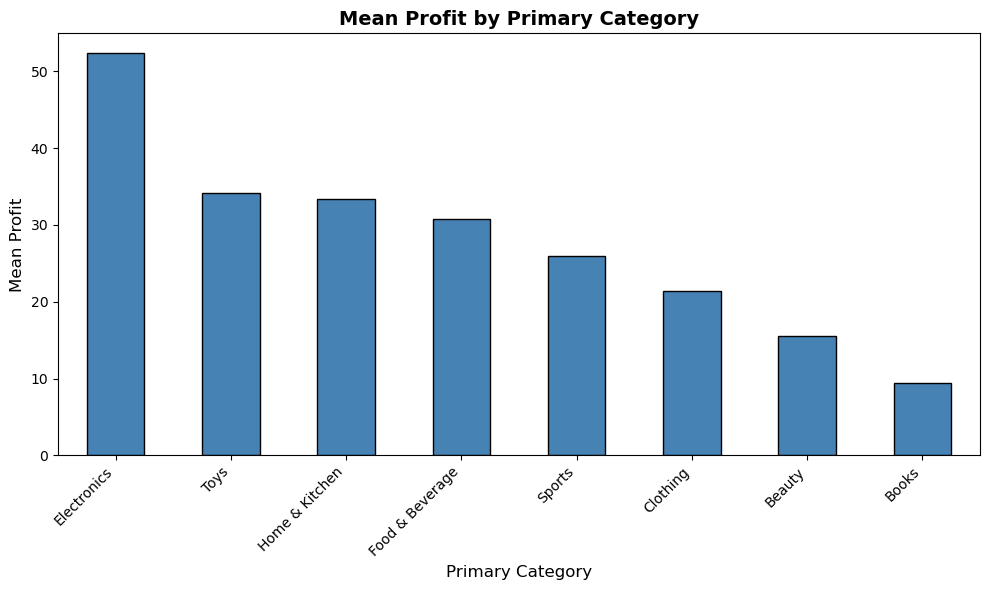

In [15]:
import matplotlib.pyplot as plt

sorted_profits = mean_profit_by_category.sort_values(ascending=False)
sorted_profits.plot(kind='bar', figsize=(10, 6), color='steelblue', edgecolor='black')

plt.title('Mean Profit by Primary Category', fontsize=14, fontweight='bold')
plt.xlabel('Primary Category', fontsize=12)
plt.ylabel('Mean Profit', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

In [16]:
comparingg_category = orders.groupby('primary_category')[['total_costs','profit']].sum()

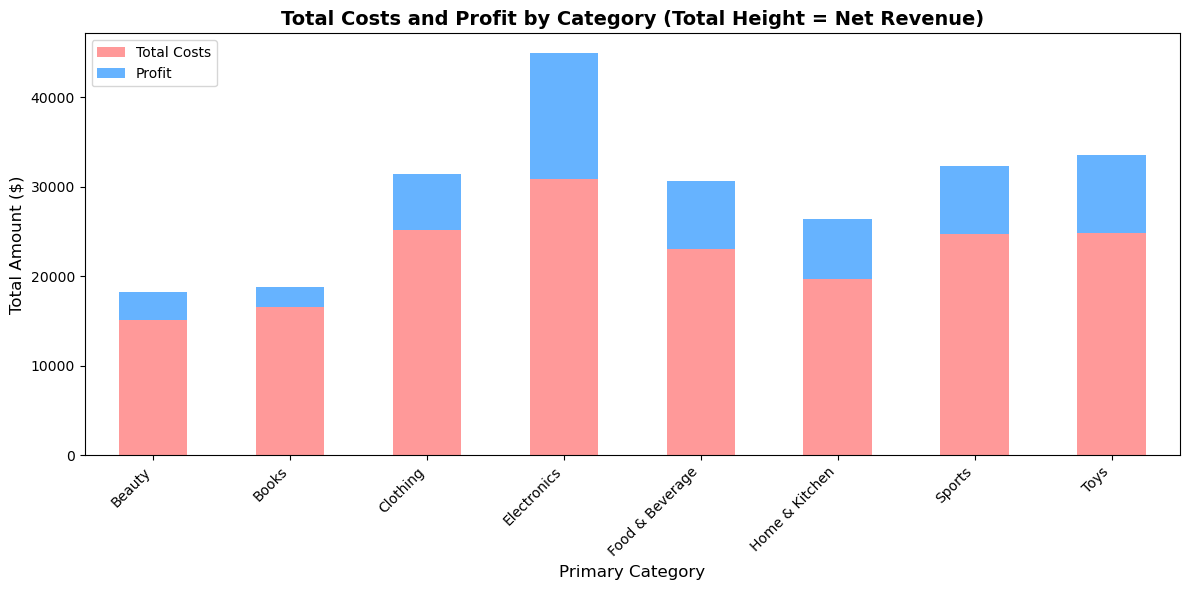

In [17]:
comparingg_category.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 6), 
    color=['#ff9999', '#66b3ff']  # Red for costs, Blue for profit
)

plt.title('Total Costs and Profit by Category (Total Height = Net Revenue)', fontsize=14, fontweight='bold')
plt.ylabel('Total Amount ($)', fontsize=12)
plt.xlabel('Primary Category', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.legend(['Total Costs', 'Profit'], loc='upper left')

plt.tight_layout()
plt.show()

## The Impact of Shipping Costs on Category Profitability
#### High shipping-to-product-cost ratios severely hamper profitability for certain categories.

In [18]:
# Analyze cost breakdowns
avg_costs = orders.groupby('primary_category')[['shipping_cost','product_cost','platform_fee','transaction_fee','discount_amount']].mean()
analysis_df = avg_costs.copy()
analysis_df['mean_profit'] = mean_profit_by_category
analysis_df['shipping_burden_pct'] = (analysis_df['shipping_cost'] / analysis_df['product_cost']) * 100
analysis_df = analysis_df.sort_values('mean_profit')
analysis_df

,shipping_cost,product_cost,platform_fee,transaction_fee,discount_amount,mean_profit,shipping_burden_pct
primary_category,,,,,,,
Books,26.204184,37.476444,2.922929,2.842385,6.107741,9.413347,69.921747
Beauty,25.234049,41.905317,3.412976,3.004683,8.544341,15.487220,60.216819
Clothing,25.408191,52.373481,4.196143,3.724061,9.976997,21.407782,48.513466
Sports,23.680548,53.738425,3.573664,3.710103,10.667740,26.015856,44.066323
Food & Beverage,26.080000,57.890972,5.122024,4.311538,10.976802,30.735911,45.050203
Home & Kitchen,24.944200,61.743350,7.207050,4.461350,10.897850,33.442850,40.399816
Toys,26.227082,60.741790,5.196109,4.369767,11.733502,34.187743,43.177986
Electronics,26.740824,75.247416,8.170225,5.618240,14.653109,52.335056,35.537199


C:\Users\shahs\AppData\Local\Temp\ipykernel_3896\1307156053.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(analysis_df.index, rotation=45, ha='right')


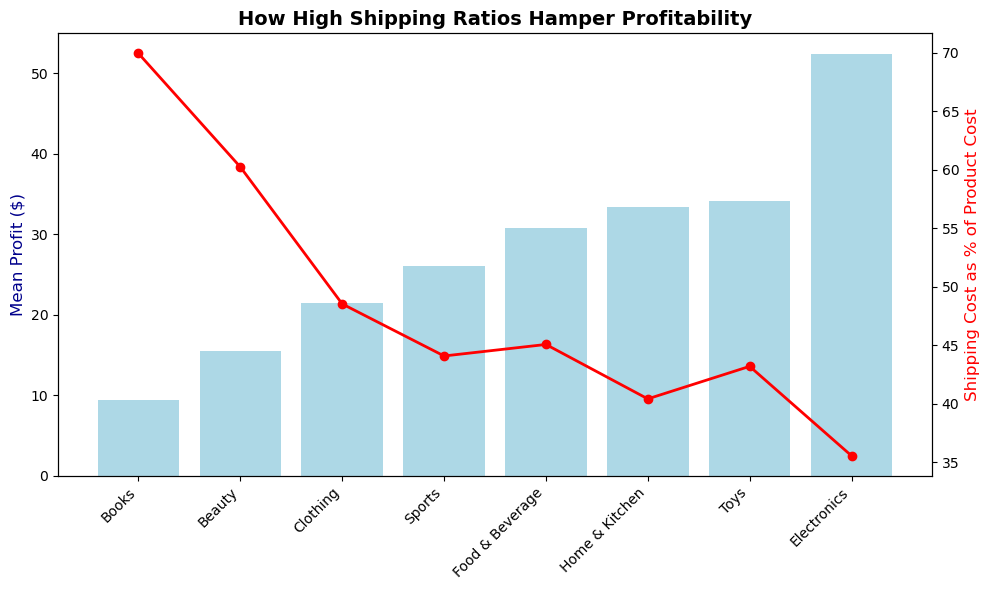

In [19]:
# Dual-axis chart: Profit vs Shipping Burden
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(analysis_df.index, analysis_df['mean_profit'], color='lightblue', label='Mean Profit')
ax1.set_ylabel('Mean Profit ($)', fontsize=12, color='darkblue')
ax1.set_xticklabels(analysis_df.index, rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(analysis_df.index, analysis_df['shipping_burden_pct'], color='red', marker='o', linewidth=2, label='Shipping % of Product Cost')
ax2.set_ylabel('Shipping Cost as % of Product Cost', fontsize=12, color='red')

plt.title('How High Shipping Ratios Hamper Profitability', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Return Rates by Category
#### Evaluating revenue leakage due to high return volume in specific product lines.

In [20]:
# Calculate return rates
yes_counts = orders[orders['returned'] == 'Yes'].groupby('primary_category').size()
total_count = orders.groupby('primary_category').size()
return_rate_by_category = ((yes_counts / total_count) * 100).fillna(0).sort_values(ascending=False)

display(return_rate_by_category.to_frame(name="Return Rate (%)").round(2))

,Return Rate (%)
primary_category,
Electronics,8.61
Books,8.37
Clothing,8.19
Sports,7.19
Toys,7.00
Home & Kitchen,6.00
Beauty,5.85
Food & Beverage,5.67


In [21]:
# Calculate total revenue lost to returns
refund_amount_by_category = orders.groupby('primary_category')['refund_amount'].sum().sort_values(ascending=False)
refund_amount_by_category

primary_category
Electronics        4078.27
Food & Beverage    3504.56
Clothing           3209.21
Toys               2469.81
Home & Kitchen     2340.10
Books              2106.36
Sports             2008.44
Beauty              865.70
Name: refund_amount, dtype: float64

In [22]:
total_lost_revenue = refund_amount_by_category.sum()
print(f"Total Estimated Revenue Lost to Returns: ${total_lost_revenue:,.2f}")

Total Estimated Revenue Lost to Returns: $20,582.45


## Sales Channel Performance
#### Comparing owned channels (Website, App) against third-party channels (Marketplace, Social) to understand the impact of platform fees.

In [23]:
mean_profit_by_channel = orders.groupby('channel')[['profit','platform_fee']].mean()
df_sorted = mean_profit_by_channel.sort_values('platform_fee')

In [24]:
df_sorted

,profit,platform_fee
channel,,
Mobile App,36.321392,0.000000
Website,31.595547,0.000000
Social Commerce,17.109340,9.872741
Marketplace,15.397446,18.973007


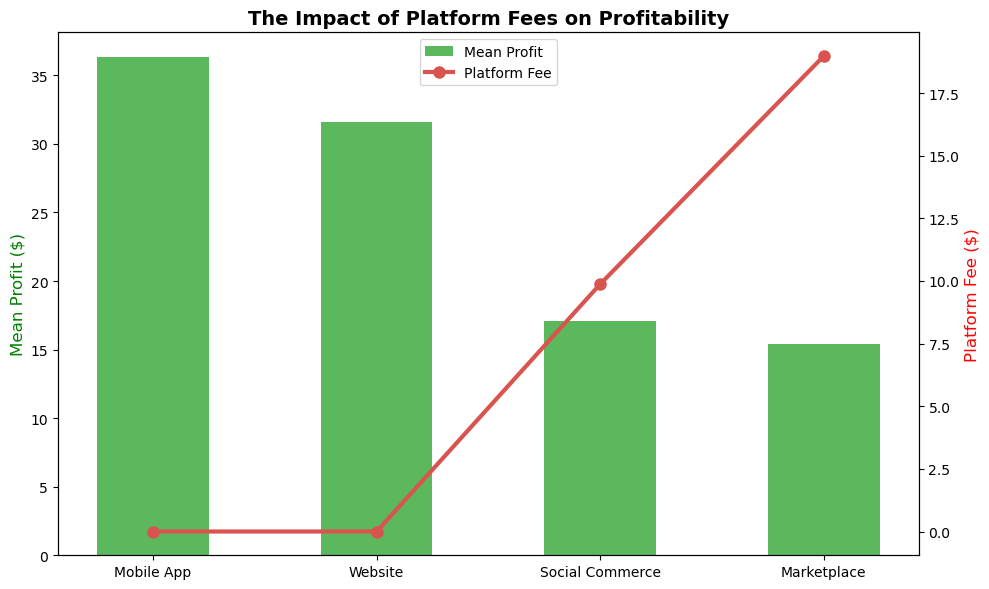

In [25]:
# Dual-axis chart: Profit vs Platform Fee
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(df_sorted.index, df_sorted['profit'], color='#5cb85c', width=0.5, label='Mean Profit')
ax1.set_ylabel('Mean Profit ($)', fontsize=12, color='green')

ax2 = ax1.twinx()
ax2.plot(df_sorted.index, df_sorted['platform_fee'], color='#d9534f', marker='o', linewidth=3, markersize=8, label='Platform Fee')
ax2.set_ylabel('Platform Fee ($)', fontsize=12, color='red')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center')

plt.title('The Impact of Platform Fees on Profitability', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Return Rates by Channel

In [26]:
# Calculate return rates by sales channel
return_rate_by_channel = (orders['returned'] == 'Yes').groupby(orders['channel']).mean() * 100
display(return_rate_by_channel.sort_values(ascending=False).to_frame(name="Return Rate (%)").round(2))

,Return Rate (%)
channel,
Social Commerce,9.14
Mobile App,7.30
Website,7.04
Marketplace,6.44


## Marketing Budget Optimization
#### Analyzing Return on Ad Spend (ROAS) to identify which platforms and months to target budget reduction.

In [27]:
Total_spend_and_recieved = market_spend[['revenue_attributed', 'spend']].sum()
total_spend_and_recieved_by_platform = market_spend.groupby('platform')[['revenue_attributed', 'spend']].sum()
total_spend_and_recieved_by_platform

,revenue_attributed,spend
platform,,
Email Marketing,117681.45,24461.37
Facebook Ads,1218572.43,106451.93
Google Ads,2194120.83,152546.48
Influencer,2216974.26,97663.12
Instagram Ads,1024639.06,65154.02
TikTok Ads,1374627.17,57229.22


In [28]:
comparison_df = (total_spend_and_recieved_by_platform / Total_spend_and_recieved) * 100
comparison_df = comparison_df.rename(columns={'revenue_attributed': '% of Total Revenue', 'spend': '% of Total Spend'}).round(2)
display(comparison_df.sort_values('% of Total Spend', ascending=False))

,% of Total Revenue,% of Total Spend
platform,,
Google Ads,26.93,30.30
Facebook Ads,14.96,21.14
Influencer,27.21,19.40
Instagram Ads,12.58,12.94
TikTok Ads,16.87,11.37
Email Marketing,1.44,4.86


In [29]:
# Calculate Average ROAS by Platform
market_spend_overview = market_spend.groupby('platform')[['spend','revenue_attributed','cpa','cpc','roas']].mean().sort_values(by='roas', ascending=False)
display(market_spend_overview[['roas', 'cpa', 'cpc']].round(2))

,roas,cpa,cpc
platform,,,
TikTok Ads,24.44,3.93,0.16
Influencer,23.45,4.80,0.19
Instagram Ads,16.99,5.55,0.23
Google Ads,13.69,6.48,0.28
Facebook Ads,11.25,8.38,0.36
Email Marketing,5.41,26.01,1.09


## Seasonal Efficiency (ROAS by Month)
#### Identifying inefficient spending periods throughout the year to apply targeted seasonal budget cuts.

In [30]:
yearly_monthly_roas = market_spend.groupby(['year', 'month_num'])['roas'].mean()
roas_comparison = yearly_monthly_roas.unstack(level='year')

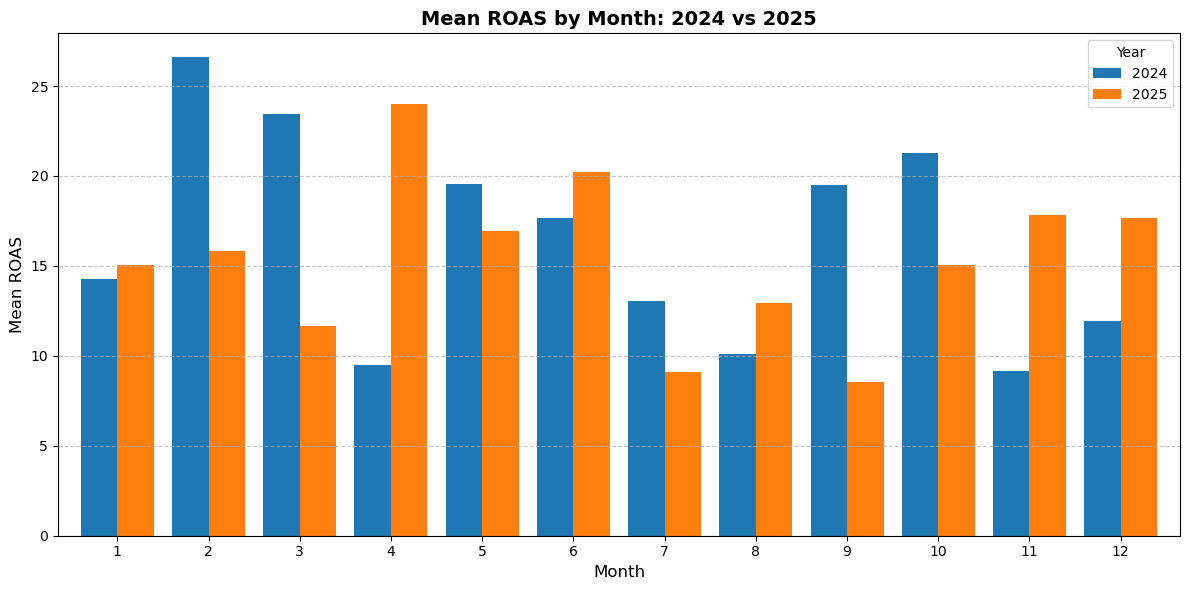

In [31]:
roas_comparison[[2024, 2025]].plot(kind='bar', figsize=(12, 6), width=0.8, color=['#1f77b4', '#ff7f0e'])
plt.title('Mean ROAS by Month: 2024 vs 2025', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Mean ROAS', fontsize=12)
plt.legend(title='Year')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

,spend,revenue_attributed,roas
month_only,,,
1,2083.634167,29452.872500,14.662500
2,2454.400833,50948.027500,21.218333
3,3171.445833,56709.660833,17.550000
4,3819.666667,60142.715833,16.734167
5,2752.530833,55009.262500,18.248333
6,3975.530000,83395.515000,18.945833
7,3922.054167,44934.093333,11.066667
8,3266.193333,40400.100833,11.527500
9,3029.586667,42473.436667,14.013333


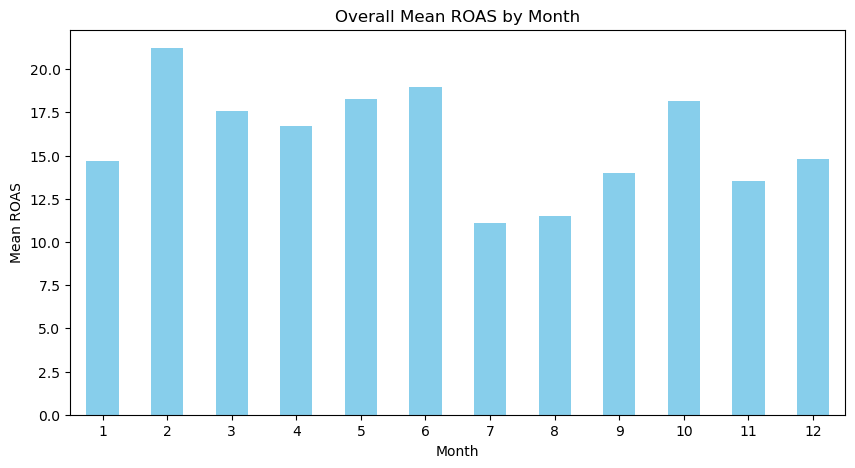

In [36]:
market_spend['date'] = pd.to_datetime(market_spend['month'])
market_spend['month_only'] = market_spend['date'].dt.month

overall_monthly_roas = market_spend.groupby('month_only')[['spend', 'revenue_attributed', 'roas']].mean()

overall_monthly_roas = overall_monthly_roas.sort_index()

display(overall_monthly_roas)

overall_monthly_roas['roas'].plot(kind='bar', figsize=(10, 5), color='skyblue')
plt.title('Overall Mean ROAS by Month')
plt.xlabel('Month')
plt.ylabel('Mean ROAS')
plt.xticks(rotation=0)
plt.show()

In [37]:
Total_spend_and_recieved = market_spend[['revenue_attributed','spend']].sum()
Total_spend_and_recieved

revenue_attributed    8146615.20
spend                  503506.14
dtype: float64

In [42]:
# Calculate % of Total Spend vs % of Total Revenue by Platform
Total_spend_and_recieved = market_spend[['revenue_attributed', 'spend']].sum()
total_spend_and_recieved_by_platform = market_spend.groupby('platform')[['revenue_attributed', 'spend']].sum()

In [43]:
comparison_df = (total_spend_and_recieved_by_platform / Total_spend_and_recieved) * 100
comparison_df = comparison_df.rename(columns={'revenue_attributed': '% of Total Revenue', 'spend': '% of Total Spend'}).round(2)
display(comparison_df.sort_values('% of Total Spend', ascending=False))

,% of Total Revenue,% of Total Spend
platform,,
Google Ads,26.93,30.30
Facebook Ads,14.96,21.14
Influencer,27.21,19.40
Instagram Ads,12.58,12.94
TikTok Ads,16.87,11.37
Email Marketing,1.44,4.86


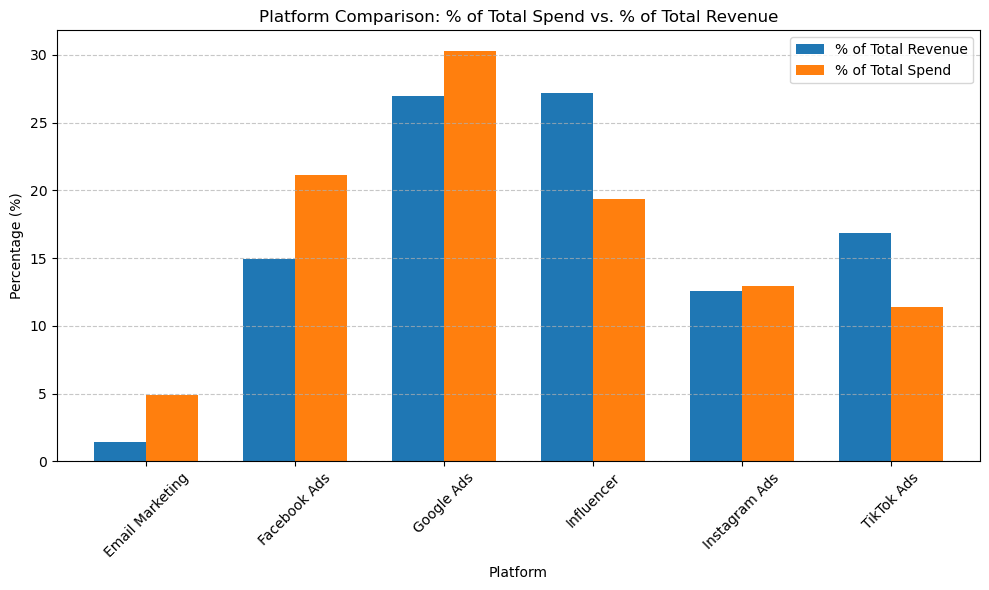

In [46]:
comparison_df.plot(kind='bar', figsize=(10, 6), width=0.7)

plt.title('Platform Comparison: % of Total Spend vs. % of Total Revenue')
plt.ylabel('Percentage (%)')
plt.xlabel('Platform')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Recommendations for Improving Profitability

## Reallocate Marketing Budget Away from Inefficient Channels:
Cut 100% of the Email Marketing budget (saving approximately ~$24,461) and reduce Facebook Ads spend by 50%. Reallocate a portion of these savings to the highly efficient TikTok Ads and Influencer channels, which generate superior ROAS. Additionally, drastically reduce overall ad spend during the mid-summer slump (July/August) and the highly competitive, low-efficiency month of November.

## Drive Traffic to Owned Sales Channels
Third-party platforms are eating margins. Marketplace and Social Commerce carry average platform fees of 18.97 USD and 9.87 USD per order, restricting average profit to 15.39 USD and 17.10 USD, respectively. Direct marketing efforts toward the Mobile App and Website, which carry 0 USD in platform fees and yield over double the profit per order (36.32 USD and 31.59 USD).

## Targeted Quality Control for High-Return Categories
lectronics (8.61% return rate), Books (8.36%), and Clothing (8.19%) are driving the highest volume of returns, representing significant revenue leakage. Implement stricter sizing guides for clothing, enhanced QA for electronics, and re-evaluate Social Commerce, which has a disproportionately high channel return rate of 9.13%.